<a href="https://www.kaggle.com/code/ashikuzzamanshishir/test-module?scriptVersionId=274180281" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:


import os, sys, shutil, random, glob, time, json, gc, math
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from tqdm import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from statsmodels.stats.contingency_tables import mcnemar

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger


try:
    import torch, timm
    from torch import nn
    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms
    TORCH_OK = True
except Exception:
    TORCH_OK = False

print("TensorFlow:", tf.__version__)
print("PyTorch ok:", TORCH_OK)


2025-11-07 07:53:18.021035: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762501998.266399      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762501998.338013      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `ty

TensorFlow: 2.18.0
PyTorch ok: True


In [2]:

DATA_DIR = "/kaggle/input/bone-fracture-dataset/Bone fracture dataset/Bone fracture dataset/Dataset"
WORK_DIR = "/kaggle/working/bone_fracture_work"
SPLIT_ROOT = os.path.join(WORK_DIR, "splits")
TRAIN_DIR = os.path.join(SPLIT_ROOT, "train")
VAL_DIR   = os.path.join(SPLIT_ROOT, "val")
TEST_DIR  = os.path.join(SPLIT_ROOT, "test")
AUG_TRAIN_DIR = os.path.join(SPLIT_ROOT, "train_aug2")
MIXT_DIR  = os.path.join(SPLIT_ROOT, "mixt")

os.makedirs(WORK_DIR, exist_ok=True)


IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10              
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


MIXT_TOTAL = 20
MIXT_PER_CLASS = MIXT_TOTAL // 2


FAST_MODE = True   


FULL_EPOCHS = 40
RUN_CNN_MODELS = not FAST_MODE
RUN_ATTENTION  = not FAST_MODE
RUN_TRANSFORMERS = (not FAST_MODE) and TORCH_OK
RUN_ENSEMBLE  = not FAST_MODE
RUN_FIVE_FOLD = not FAST_MODE
RUN_OPTUNA    = False  # Optional; off by default

print("FAST_MODE:", FAST_MODE)
print("WORK_DIR:", WORK_DIR)


FAST_MODE: True
WORK_DIR: /kaggle/working/bone_fracture_work


In [3]:
IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
classes = sorted(classes)
assert len(classes) == 2, f"Expected 2 classes; found {classes}"
print("Detected classes:", classes)

all_paths = {c: sorted([p for p in glob.glob(os.path.join(DATA_DIR, c, "**"), recursive=True)
                        if os.path.isfile(p) and p.lower().endswith(IMG_EXT)])
             for c in classes}
counts = {c: len(all_paths[c]) for c in classes}
print("Image counts:", counts, "| Total:", sum(counts.values()))


Detected classes: ['fracture', 'normal']
Image counts: {'fracture': 2000, 'normal': 127} | Total: 2127


In [4]:
if os.path.exists(SPLIT_ROOT):
    shutil.rmtree(SPLIT_ROOT)

for root in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for c in classes:
        os.makedirs(os.path.join(root, c), exist_ok=True)

for c in classes:
    paths = all_paths[c]
    temp, test_c = train_test_split(paths, test_size=TEST_SPLIT, random_state=SEED, shuffle=True)
    rel_val = VAL_SPLIT / (1.0 - TEST_SPLIT)
    train_c, val_c = train_test_split(temp, test_size=rel_val, random_state=SEED, shuffle=True)
    for src in train_c:
        shutil.copy2(src, os.path.join(TRAIN_DIR, c, os.path.basename(src)))
    for src in val_c:
        shutil.copy2(src, os.path.join(VAL_DIR, c, os.path.basename(src)))
    for src in test_c:
        shutil.copy2(src, os.path.join(TEST_DIR, c, os.path.basename(src)))

def count_dir(root):
    return {c: len(glob.glob(os.path.join(root, c, "*"))) for c in classes}

print("Split counts:")
print("Train:", count_dir(TRAIN_DIR))
print("Val  :", count_dir(VAL_DIR))
print("Test :", count_dir(TEST_DIR))


Split counts:
Train: {'fracture': 1400, 'normal': 88}
Val  : {'fracture': 300, 'normal': 19}
Test : {'fracture': 300, 'normal': 20}


In [5]:
def preprocess_image_np(img_rgb_uint8):
    lab = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, A, B])
    rgb2 = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    rgb2 = cv2.GaussianBlur(rgb2, (3,3), 0)   # optional denoise
    rgb2 = rgb2.astype(np.float32) / 255.0
    return rgb2

def preprocessing_function(img):
    img = np.clip(img, 0, 255).astype(np.uint8)
    return preprocess_image_np(img)

def load_resize_rgb(path, size=IMG_SIZE):
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    x = cv2.resize(x, size, interpolation=cv2.INTER_AREA)
    return x


In [6]:
sample_files = []
for c in classes:
    pool = glob.glob(os.path.join(TRAIN_DIR, c, "*"))
    sample_files += random.sample(pool, min(8, len(pool)))

psnr_vals, ssim_vals = [], []
for p in sample_files:
    raw = load_resize_rgb(p)
    proc = (preprocess_image_np(raw) * 255.0).astype(np.uint8)
    psnr_vals.append(psnr(raw, proc, data_range=255))
    ssim_vals.append(ssim(raw, proc, channel_axis=2, data_range=255))

print(f"Sample size: {len(sample_files)} | Avg PSNR: {np.mean(psnr_vals):.3f} dB | Avg SSIM: {np.mean(ssim_vals):.4f}")


Sample size: 16 | Avg PSNR: 24.831 dB | Avg SSIM: 0.8898


In [7]:
if os.path.exists(AUG_TRAIN_DIR):
    shutil.rmtree(AUG_TRAIN_DIR)
for c in classes:
    os.makedirs(os.path.join(AUG_TRAIN_DIR, c), exist_ok=True)

aug_gen_1 = ImageDataGenerator(
    preprocessing_function=preprocessing_function,
    rotation_range=12, width_shift_range=0.08, height_shift_range=0.08,
    zoom_range=0.12, horizontal_flip=True, fill_mode="nearest"
)
aug_gen_2 = ImageDataGenerator(
    preprocessing_function=preprocessing_function,
    rotation_range=8, width_shift_range=0.06, height_shift_range=0.06,
    zoom_range=0.10, horizontal_flip=True, shear_range=6, fill_mode="nearest"
)

def save_aug_versions(input_dir, out_dir, versions=2):
    for c in classes:
        cur = glob.glob(os.path.join(input_dir, c, "*"))
        for src in tqdm(cur, desc=f"Aug {c}"):
            base = os.path.splitext(os.path.basename(src))[0]
            img = load_resize_rgb(src, IMG_SIZE)
            for k in range(versions):
                gen = aug_gen_1 if k == 0 else aug_gen_2
                x = tf.keras.preprocessing.image.img_to_array(img).astype(np.float32)
                x = np.expand_dims(x, 0)
                aug_iter = gen.flow(x, batch_size=1, shuffle=False)
                aug = next(aug_iter)[0]     # already preprocessed to [0,1]
                out = (aug * 255).astype(np.uint8)
                out_path = os.path.join(out_dir, c, f"{base}_aug{k+1}.jpg")
                cv2.imwrite(out_path, cv2.cvtColor(out, cv2.COLOR_RGB2BGR))

save_aug_versions(TRAIN_DIR, AUG_TRAIN_DIR, versions=2)
print("Aug counts:", count_dir(AUG_TRAIN_DIR))


Aug normal: 100%|██████████| 88/88 [00:08<00:00, 10.63it/s]

Aug counts: {'fracture': 2800, 'normal': 176}


In [8]:
train_gen = ImageDataGenerator(preprocessing_function=preprocessing_function)
val_test_gen = ImageDataGenerator(preprocessing_function=preprocessing_function)

train_flow = train_gen.flow_from_directory(AUG_TRAIN_DIR, target_size=IMG_SIZE,
                                           batch_size=BATCH_SIZE, class_mode="binary", shuffle=True, seed=SEED)
val_flow = val_test_gen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
                                           batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)
test_flow = val_test_gen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
                                            batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

idx_to_class = {v:k for k,v in train_flow.class_indices.items()}
classes_ordered = [k for k,_ in sorted(train_flow.class_indices.items(), key=lambda x:x[1])]
print("Class indices:", train_flow.class_indices)


Found 2976 images belonging to 2 classes.
Found 319 images belonging to 2 classes.
Found 320 images belonging to 2 classes.
Class indices: {'fracture': 0, 'normal': 1}


In [9]:
def binary_metrics(y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = (tp+tn)/cm.sum()
    ppv = tp/(tp+fp+1e-9)         
    npv = tn/(tn+fn+1e-9)
    sens = tp/(tp+fn+1e-9)        
    spec = tn/(tn+fp+1e-9)
    f1 = 2*ppv*sens/(ppv+sens+1e-9)
    return {"accuracy":acc, "precision":ppv, "recall":sens, "specificity":spec, "npv":npv, "f1":f1, "cm":cm}

def bootstrap_accuracy(y_true, y_pred, n=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    accs = [accuracy_score(y_true[rng.choice(idx, size=len(idx), replace=True)],
                           y_pred[rng.choice(idx, size=len(idx), replace=True)]) for _ in range(n)]
    lo, hi = np.percentile(accs, [2.5, 97.5])
    return {"mean": float(np.mean(accs)), "ci95": (float(lo), float(hi))}

class Timer:
    def __enter__(self): self.t0=time.time(); return self
    def __exit__(self,*exc): self.elapsed=time.time()-self.t0


In [10]:
from tensorflow.keras.applications import EfficientNetB0

L2 = 1e-4
DROP = 0.5

def build_efficientnet():
    base = EfficientNetB0(include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), weights="imagenet")
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(DROP)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(L2))(x)
    m = models.Model(base.input, out, name="EfficientNetB0_bin")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m, base

E = FULL_EPOCHS if not FAST_MODE else EPOCHS
m, base = build_efficientnet()
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5 if not FAST_MODE else 3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(WORK_DIR,"best_effb0.h5"), monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]
with Timer() as ttrain:
    hist = m.fit(train_flow, validation_data=val_flow, epochs=E, verbose=1)

print(f"Train time (s): {ttrain.elapsed:.1f}")


2025-11-07 07:55:07.010453: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 132s 616ms/step - accuracy: 0.8984 - loss: 0.2998 - val_accuracy: 0.9404 - val_loss: 0.2267
Epoch 2/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 113s 605ms/step - accuracy: 0.9377 - loss: 0.2364 - val_accuracy: 0.9404 - val_loss: 0.2308
Epoch 3/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 112s 604ms/step - accuracy: 0.9420 - loss: 0.2233 - val_accuracy: 0.9404 - val_loss: 0.2312
Epoch 4/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 143s 609ms/step - accuracy: 0.9403 - loss: 0.2301 - val_accuracy: 0.9404 - val_loss: 0.2277
Epoch 5/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 113s 607ms/step - accuracy: 0.9359 - loss: 0.2444 - val_accuracy: 0.9404 - val_loss: 0.2262
Epoch 6/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 114s 614ms/step - accuracy: 0.9407 - loss: 0.2315 - val_accuracy: 0.9404 - val_loss: 0.2268
Epoch 7/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 111s 597ms/step - accuracy: 0.9442 - loss: 0.2197 - val_accuracy: 0.9404 - val_loss: 0.2271
Epoch 8/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 121s 652ms/step - accuracy: 0.9387 -

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classif

== Train ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97      2800
      normal       0.00      0.00      0.00       176

    accuracy                           0.94      2976
   macro avg       0.47      0.50      0.48      2976
weighted avg       0.89      0.94      0.91      2976

== Val ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        19

    accuracy                           0.94       319
   macro avg       0.47      0.50      0.48       319
weighted avg       0.88      0.94      0.91       319

== Test ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.

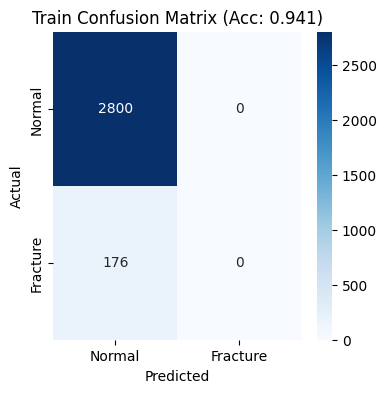

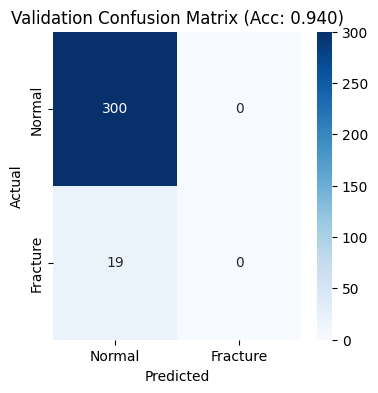

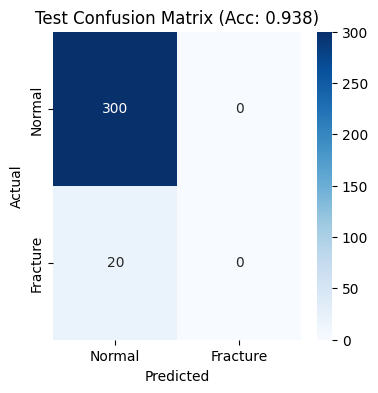

In [11]:

#  Evaluation with Confusion Matrices (Train / Val / Test)

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def eval_gen(model, gen):
    """Evaluate model on a generator and compute metrics."""
    loss, acc = model.evaluate(gen, verbose=0)
    prob = model.predict(gen, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    y = gen.classes
    met = binary_metrics(y, pred, prob)
    rep = classification_report(y, pred, target_names=classes_ordered)
    boot = bootstrap_accuracy(y, pred, 1000 if not FAST_MODE else 200)
    return {"loss":loss,"acc":acc,"metrics":met,"report":rep,"boot_acc":boot, "y":y, "pred":pred}


train_eval = eval_gen(m, train_flow)
val_eval   = eval_gen(m, val_flow)
test_eval  = eval_gen(m, test_flow)

# Print reports
print("== Train ==")
print(train_eval["report"])
print("== Val ==")
print(val_eval["report"])
print("== Test ==")
print(test_eval["report"])
print("Bootstrap Acc (test):", test_eval["boot_acc"])


splits = {
    "Train": train_eval,
    "Validation": val_eval,
    "Test": test_eval
}

for name, result in splits.items():
    y_true = result["y"]
    y_pred = result["pred"]
    cm = confusion_matrix(y_true, y_pred)
    acc = result["acc"]
    
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fracture"],
                yticklabels=["Normal", "Fracture"])
    plt.title(f"{name} Confusion Matrix (Acc: {acc:.3f})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


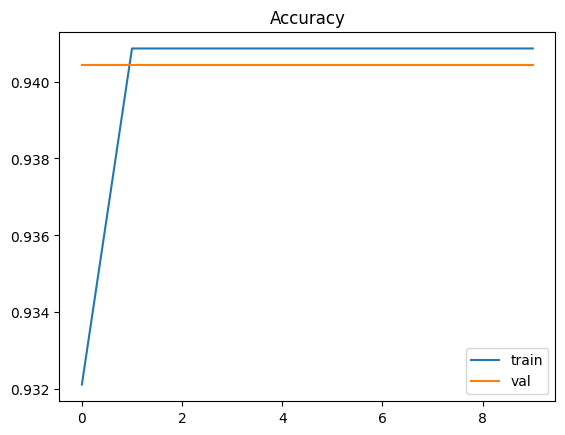

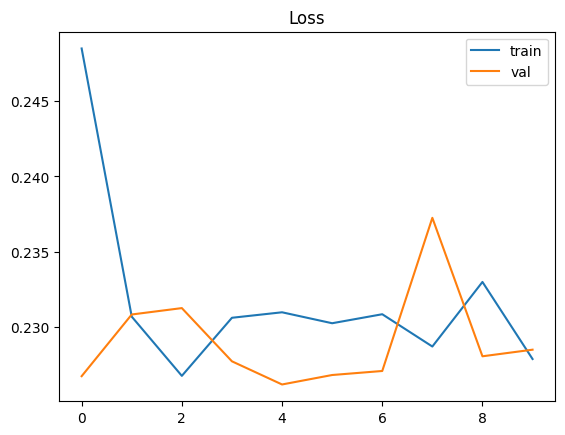

In [12]:
plt.figure(); plt.plot(hist.history["accuracy"], label="train"); plt.plot(hist.history.get("val_accuracy",[]), label="val")
plt.title("Accuracy"); plt.legend(); plt.show()
plt.figure(); plt.plot(hist.history["loss"], label="train"); plt.plot(hist.history.get("val_loss",[]), label="val")
plt.title("Loss"); plt.legend(); plt.show()


 Using main dataset folder: /kaggle/input/bone-fracture-dataset/Bone fracture dataset/Bone fracture dataset/Dataset
📸 Found 2127 total images (fracture + normal)
Using device: /CPU:0
Running Grad-CAM on 5 random images from main dataset...

🩻 [1] 673.png


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


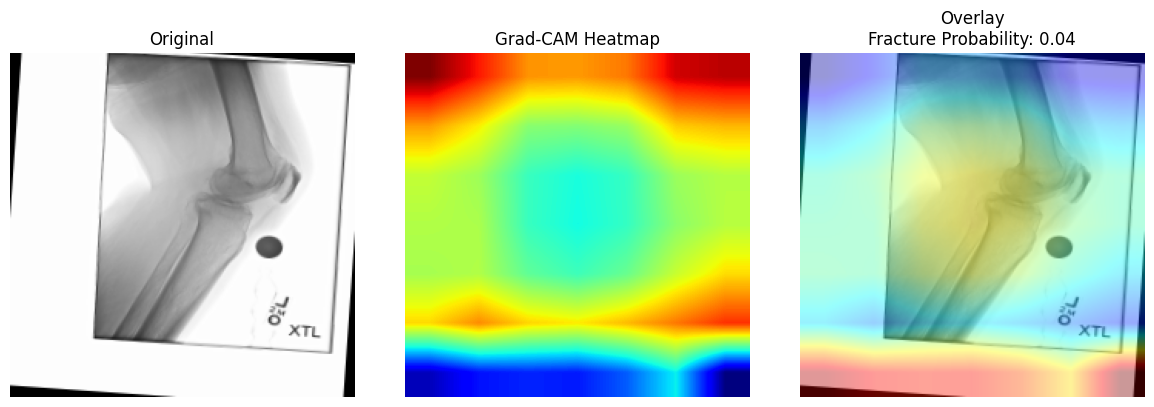


🩻 [2] 1839.png


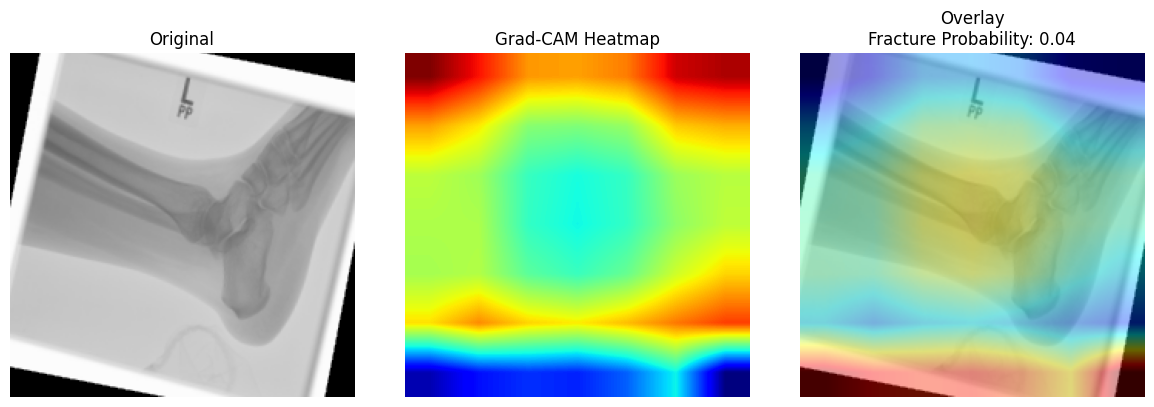


🩻 [3] 112.png


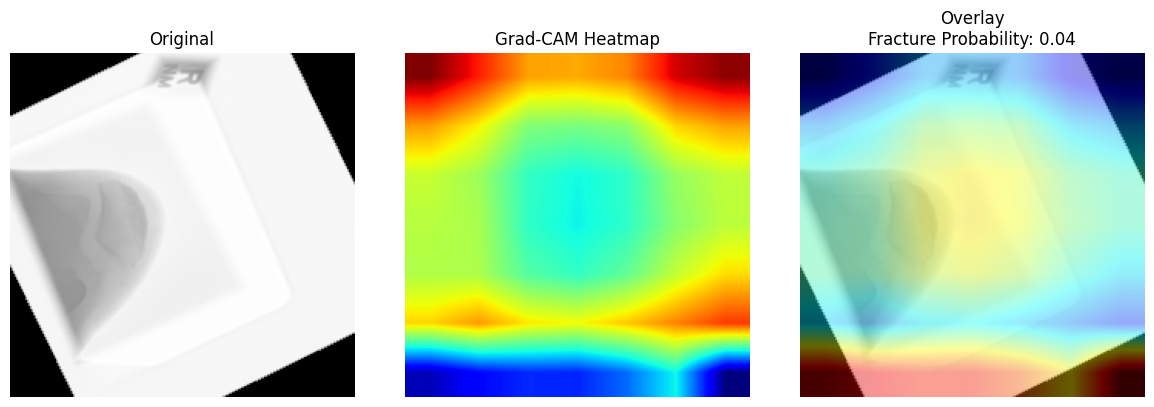


🩻 [4] 1334.png


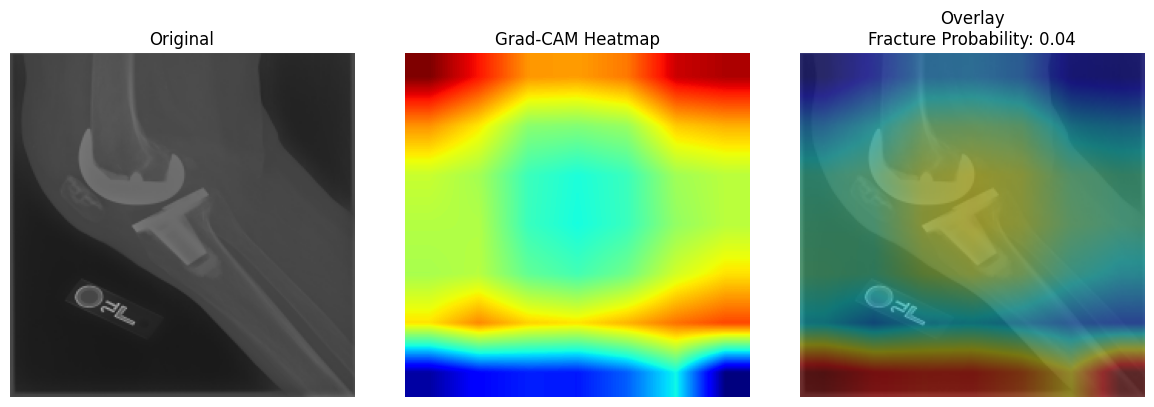


🩻 [5] 671.png


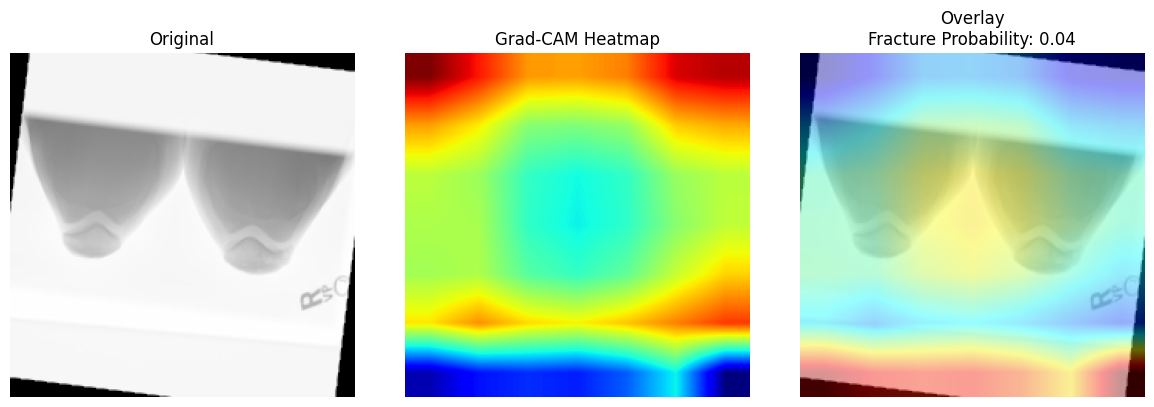

In [13]:
# ==========================================================
#  Grad-CAM Visualization 
# ==========================================================
import os, glob, random, cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


root_candidates = [
    "/kaggle/input/bone-fracture-dataset/",
    "/kaggle/input/bone-fracture-dataset-only/",
    "/kaggle/input/"
]

SOURCE_MAIN = None
for root in root_candidates:
    for subdir, dirs, files in os.walk(root):
        if "fracture" in dirs and "normal" in dirs:
            SOURCE_MAIN = subdir
            break
    if SOURCE_MAIN:
        break

if not SOURCE_MAIN:
    raise FileNotFoundError(" Could not locate main dataset folder containing 'fracture' and 'normal'!")

print(f" Using main dataset folder: {SOURCE_MAIN}")


all_imgs = glob.glob(os.path.join(SOURCE_MAIN, "fracture", "*.*")) + \
           glob.glob(os.path.join(SOURCE_MAIN, "normal", "*.*"))
all_imgs = [f for f in all_imgs if f.lower().endswith(("jpg", "jpeg", "png"))]

if not all_imgs:
    raise RuntimeError("❌ No images found inside main dataset folder!")

print(f"📸 Found {len(all_imgs)} total images (fracture + normal)")


if "m" in globals():
    model_to_use = m
elif "models_list" in globals() and len(models_list) > 0:
    model_to_use = models_list[0]
else:
    raise RuntimeError("No trained model found! Please train or load a model first.")

device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f"Using device: {device_name}")


def load_rgb(img_path, size=(224, 224)):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f" Cannot read: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

def grad_cam(model, img_path, size=(224, 224)):
    raw = load_rgb(img_path, size)
    x = np.expand_dims(raw.astype(np.float32) / 255.0, axis=0)

    # Find last conv layer
    last_conv = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name
            break
    if last_conv is None:
        raise ValueError(" No Conv2D layer found in model.")

    grad_model = tf.keras.models.Model([model.inputs],
                                       [model.get_layer(last_conv).output, model.output])

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()
    conv_output = conv_out[0].numpy()

    for i in range(pooled_grads.shape[-1]):
        conv_output[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_output, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)
    heatmap = cv2.resize(heatmap, (raw.shape[1], raw.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(raw, 0.6, heatmap_color, 0.4, 0)

    return raw, heatmap, overlay, float(preds.numpy()[0][0])


num_samples = 5
chosen_imgs = random.sample(all_imgs, min(num_samples, len(all_imgs)))
print(f"Running Grad-CAM on {len(chosen_imgs)} random images from main dataset...")

for i, img_path in enumerate(chosen_imgs, 1):
    print(f"\n🩻 [{i}] {os.path.basename(img_path)}")
    raw, hm, ov, prob = grad_cam(model_to_use, img_path)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(raw); plt.title("Original"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(hm, cmap="jet"); plt.title("Grad-CAM Heatmap"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(ov); plt.title(f"Overlay\nFracture Probability: {prob:.2f}"); plt.axis("off")
    plt.tight_layout()
    plt.show()


 No GPU found — using CPU.
 Starting CNN training & evaluation for all backbones...

==================== ResNet50 ====================
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Training ResNet50 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8999 - loss: 0.3201
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/ResNet50_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.9000 - loss: 0.3198 - val_accuracy: 0.9404 - val_loss: 0.2258 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9424 - loss: 0.2265
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.9424 - loss: 0.2265 - val_accuracy: 0.9404 - val_loss: 0.2346 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9379 - loss: 0.2344
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



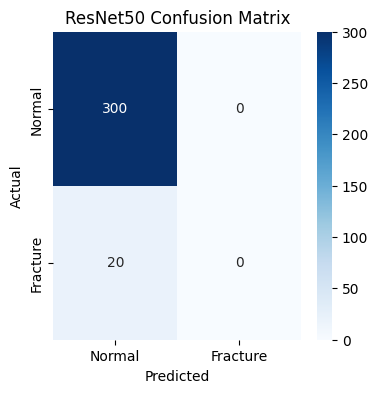

==================== VGG16 ====================
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training VGG16 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8839 - loss: 0.3462
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/VGG16_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 798s 4s/step - accuracy: 0.8841 - loss: 0.3458 - val_accuracy: 0.9404 - val_loss: 0.2191 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9381 - loss: 0.2336
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 796s 4s/step - accuracy: 0.9381 - loss: 0.2335 - val_accuracy: 0.9404 - val_loss: 0.2172 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9459 - loss: 0.2065
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 801s 4s/step - accuracy: 0.9458 - loss: 0.2065 - val_accuracy: 0.9404 - val_loss: 0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



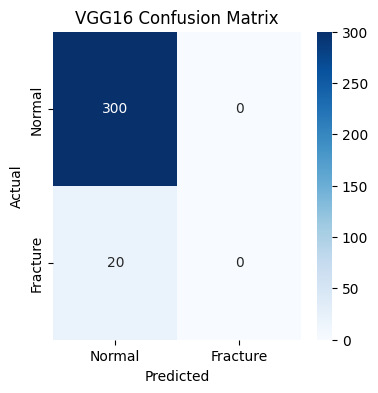

==================== InceptionV3 ====================
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training InceptionV3 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.9223 - loss: 0.2889
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/InceptionV3_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 190s 954ms/step - accuracy: 0.9224 - loss: 0.2886 - val_accuracy: 0.9404 - val_loss: 0.2091 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.9382 - loss: 0.1648
Epoch 2: val_accuracy improved from 0.94044 to 0.94671, saving model to /kaggle/working/bone_fracture_work/InceptionV3_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 170s 911ms/step - accuracy: 0.9382 - loss: 0.1648 - val_accuracy: 0.9467 - val_loss: 0.1702 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.9500 - loss: 0.1434
Epoch 3: val_accuracy improved from 0.94671 to 0.94984,

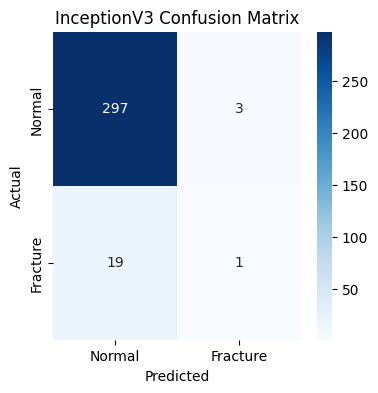

==================== Xception ====================
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Training Xception for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9340 - loss: 0.2487
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/Xception_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.9340 - loss: 0.2486 - val_accuracy: 0.9404 - val_loss: 0.2025 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9416 - loss: 0.1699
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.9416 - loss: 0.1699 - val_accuracy: 0.9404 - val_loss: 0.1742 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9419 - loss: 0.1534
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.9419 - loss: 0.1533 - val_accuracy: 0.9373 - val

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



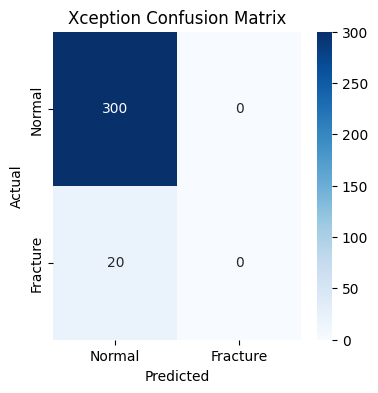

==================== DenseNet121 ====================
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training DenseNet121 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8966 - loss: 0.3067
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/DenseNet121_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.8967 - loss: 0.3065 - val_accuracy: 0.9404 - val_loss: 0.2077 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9325 - loss: 0.2208
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.9326 - loss: 0.2207 - val_accuracy: 0.9373 - val_loss: 0.1931 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9391 - loss: 0.1866
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9391 - loss: 0.1866 - val_accuracy: 0.9

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



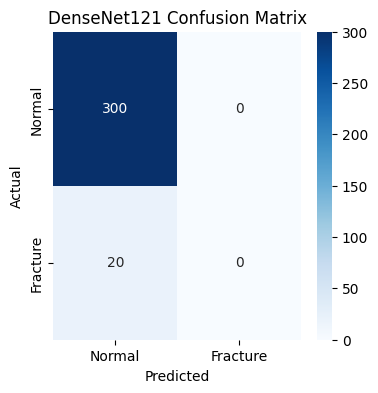

==================== MobileNetV2 ====================


/tmp/ipykernel_13/879226839.py:52: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training MobileNetV2 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9126 - loss: 0.2898
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/MobileNetV2_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 80s 387ms/step - accuracy: 0.9127 - loss: 0.2895 - val_accuracy: 0.9404 - val_loss: 0.2102 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9376 - loss: 0.1810
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 69s 370ms/step - accuracy: 0.9376 - loss: 0.1809 - val_accuracy: 0.9404 - val_loss: 0.1888 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9417 - loss: 0.1629
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 65s 351ms/step - accuracy: 0.9417 - loss: 0.1628 - val_accuracy: 0.9216 - val_loss: 0.1894 - learning_rate: 0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



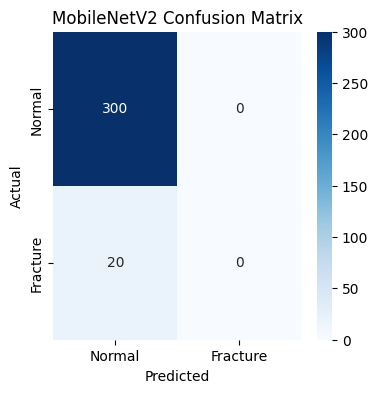

==================== EfficientNetB0 ====================

Training EfficientNetB0 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9417 - loss: 0.2501
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EfficientNetB0_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 136s 641ms/step - accuracy: 0.9417 - loss: 0.2500 - val_accuracy: 0.9404 - val_loss: 0.2260 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.9416 - loss: 0.2279
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 111s 599ms/step - accuracy: 0.9416 - loss: 0.2279 - val_accuracy: 0.9404 - val_loss: 0.2260 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.9407 - loss: 0.2288
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 150s 644ms/step 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



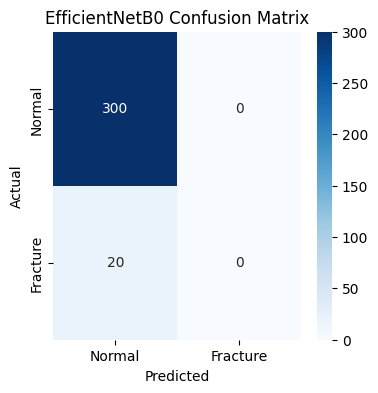

==================== NASNetMobile ====================
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training NASNetMobile for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.8999 - loss: 0.2984
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/NASNetMobile_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 162s 689ms/step - accuracy: 0.9001 - loss: 0.2981 - val_accuracy: 0.9404 - val_loss: 0.1928 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.9399 - loss: 0.1930
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 114s 612ms/step - accuracy: 0.9399 - loss: 0.1930 - val_accuracy: 0.9404 - val_loss: 0.1750 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.9399 - loss: 0.1773
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 115s 617ms/step - accuracy: 0.9399 - loss: 0.177

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



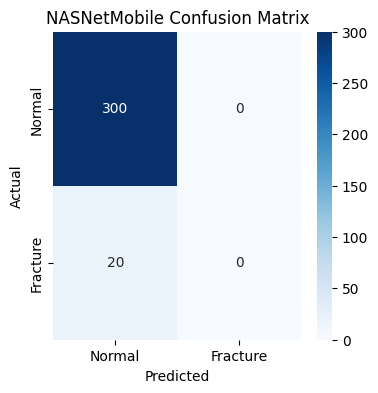


 CNN Leaderboard (Test Split):


,Model,Accuracy,F1-score,Precision,Recall,Specificity
0,ResNet50,0.93750,0.000000,0.00,0.00,1.00
1,VGG16,0.93750,0.000000,0.00,0.00,1.00
2,Xception,0.93750,0.000000,0.00,0.00,1.00
3,DenseNet121,0.93750,0.000000,0.00,0.00,1.00
4,MobileNetV2,0.93750,0.000000,0.00,0.00,1.00
5,EfficientNetB0,0.93750,0.000000,0.00,0.00,1.00
6,NASNetMobile,0.93750,0.000000,0.00,0.00,1.00
7,InceptionV3,0.93125,0.083333,0.25,0.05,0.99


In [14]:
# ==========================================================
# 8 CNN Backbones Training + Evaluation 
# ==========================================================
import os, gc
import pandas as pd
import tensorflow as tf
from IPython.display import display
from tensorflow.keras.applications import (
    ResNet50, VGG16, InceptionV3, Xception, DenseNet121,
    MobileNetV2, EfficientNetB0, NASNetMobile
)
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


RUN_CNN_MODELS = True
FULL_EPOCHS = 5
DROP = 0.5
L2 = 1e-4
IMG_SIZE = (224, 224)
WORK_DIR = "/kaggle/working/bone_fracture_work"
os.makedirs(WORK_DIR, exist_ok=True)


gpus = tf.config.list_physical_devices('GPU')
if gpus:
    device_name = "/GPU:0"
    print("Using GPU for training:", gpus[0].name)
else:
    device_name = "/CPU:0"
    print(" No GPU found — using CPU.")


def build_keras_backbone(name):
    """Builds and compiles a CNN backbone model."""
    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    if name == "ResNet50":
        base = ResNet50(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "VGG16":
        base = VGG16(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "InceptionV3":
        base = InceptionV3(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "Xception":
        base = Xception(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "DenseNet121":
        base = DenseNet121(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "MobileNetV2":
        base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "EfficientNetB0":
        base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "NASNetMobile":
        base = NASNetMobile(include_top=False, weights="imagenet", input_tensor=inputs)
    else:
        raise ValueError(f"Unknown backbone: {name}")

    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(DROP)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(L2))(x)
    m = models.Model(inputs, out, name=f"{name}_bin")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m, base


def fit_eval_model(model, name):
    """Trains a CNN and evaluates it using eval_gen."""
    E = FULL_EPOCHS
    ckpt_path = os.path.join(WORK_DIR, f"{name}_best.h5")

    cbs = [
        EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, verbose=1),
    ]

    print(f"\nTraining {name} for {E} epochs...")
    with tf.device(device_name):
        history = model.fit(
            train_flow,
            validation_data=val_flow,
            epochs=E,
            callbacks=cbs,
            verbose=1
        )

    print(f"\n Evaluating {name} on test data...")
    with tf.device(device_name):
        result = eval_gen(model, test_flow)

    # Handle dict-style eval_gen
    if isinstance(result, dict):
        res = result
        pred = res["pred"]
        y = res["y"]
        prob = None
    else:
        res, pred, prob, y = result

    print("Classification report:\n", res["report"])

    # Confusion Matrix
    cm = confusion_matrix(y, pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fracture"], yticklabels=["Normal", "Fracture"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return res, pred, prob, y, history


if RUN_CNN_MODELS:
    cnn_list = [
        "ResNet50", "VGG16", "InceptionV3", "Xception",
        "DenseNet121", "MobileNetV2", "EfficientNetB0", "NASNetMobile"
    ]
    results_cnn = []

    print(" Starting CNN training & evaluation for all backbones...\n")
    for arch in cnn_list:
        print(f"==================== {arch} ====================")
        tf.keras.backend.clear_session()
        gc.collect()

        with tf.device(device_name):
            m2, _ = build_keras_backbone(arch)
            res, pred, prob, y, hist = fit_eval_model(m2, arch)
            results_cnn.append({
                "name": arch,
                "test": res,
                "pred": pred,
                "prob": prob,
                "y": y
            })

        tf.keras.backend.clear_session()
        gc.collect()

    # Leaderboard
    df = pd.DataFrame(
        [[r["name"],
          float(r["test"]["acc"]),
          float(r["test"]["metrics"]["f1"]),
          float(r["test"]["metrics"]["precision"]),
          float(r["test"]["metrics"]["recall"]),
          float(r["test"]["metrics"]["specificity"])]
         for r in results_cnn],
        columns=["Model","Accuracy","F1-score","Precision","Recall","Specificity"]
    ).sort_values("Accuracy", ascending=False)

    print("\n CNN Leaderboard (Test Split):")
    display(df.reset_index(drop=True))
else:
    print("RUN_CNN_MODELS is False — manually force it True if you want to train CNNs.")


CBAM setup → RUN_ATTENTION: True | device: /CPU:0 | classes_ordered: ['fracture', 'normal']

 Training EffB0_PLAIN for 3 epochs…
Epoch 1/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.9255 - loss: 0.2850
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EffB0_PLAIN_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 133s 620ms/step - accuracy: 0.9256 - loss: 0.2848 - val_accuracy: 0.9404 - val_loss: 0.2362 - learning_rate: 0.0010
Epoch 2/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.9364 - loss: 0.2429
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 109s 588ms/step - accuracy: 0.9364 - loss: 0.2429 - val_accuracy: 0.9404 - val_loss: 0.2283 - learning_rate: 0.0010
Epoch 3/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.9384 - loss: 0.2377
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 110s 593ms/step - accuracy: 0.9384 - loss: 0.2377 - val_accuracy:

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



== EffB0_PLAIN (test) ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



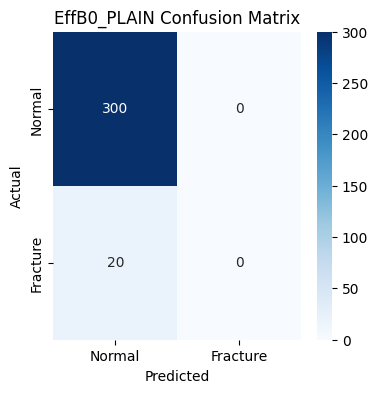


 Training EffB0_CBAM for 3 epochs…
Epoch 1/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.9385 - loss: 0.2731
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EffB0_CBAM_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 150s 699ms/step - accuracy: 0.9385 - loss: 0.2730 - val_accuracy: 0.9404 - val_loss: 0.2288 - learning_rate: 0.0010
Epoch 2/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.9389 - loss: 0.2347
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 115s 616ms/step - accuracy: 0.9389 - loss: 0.2346 - val_accuracy: 0.9404 - val_loss: 0.2268 - learning_rate: 0.0010
Epoch 3/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9400 - loss: 0.2306
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 114s 612ms/step - accuracy: 0.9400 - loss: 0.2306 - val_accuracy: 0.9404 - val_loss: 0.2260 - learning_rate: 0.0010
Restoring model weights from the end of the

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



== EffB0_CBAM (test) ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



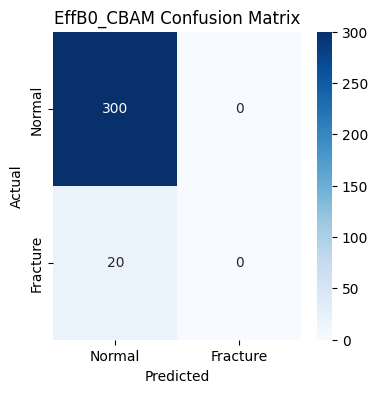


🧪 McNemar: b=0, c=0, p-value=1.000000


In [15]:
# ==========================================================
# enable + train + evaluate + McNemar 
# ==========================================================
import os, gc, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import backend as K
from statsmodels.stats.contingency_tables import mcnemar


RUN_ATTENTION = True
if "IMG_SIZE" not in globals(): IMG_SIZE = (224, 224)
if "DROP" not in globals(): DROP = 0.5
if "L2" not in globals(): L2 = 1e-4
if "FULL_EPOCHS" not in globals(): FULL_EPOCHS = 5
if "FAST_MODE" not in globals(): FAST_MODE = False
if "WORK_DIR" not in globals(): WORK_DIR = "/kaggle/working/bone_fracture_work"
if "classes_ordered" not in globals(): classes_ordered = ["fracture","normal"]
os.makedirs(WORK_DIR, exist_ok=True)


device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print("CBAM setup → RUN_ATTENTION:", RUN_ATTENTION, "| device:", device_name, "| classes_ordered:", classes_ordered)


def cbam_block(inp, r=8, name="cbam"):
    c = K.int_shape(inp)[-1]
    assert c is not None, "CBAM needs known channel dimension"
    c_mid = max(1, c // r)

    gap = layers.GlobalAveragePooling2D(name=f"{name}_gap")(inp)
    gmp = layers.GlobalMaxPooling2D(name=f"{name}_gmp")(inp)
    shared_mlp = tf.keras.Sequential([
        layers.Dense(c_mid, activation="relu", name=f"{name}_fc1"),
        layers.Dense(c, activation=None, name=f"{name}_fc2"),
    ], name=f"{name}_mlp")
    ch = layers.Add(name=f"{name}_ch_add")([shared_mlp(gap), shared_mlp(gmp)])
    ch = layers.Activation("sigmoid", name=f"{name}_ch_sig")(ch)
    ch = layers.Reshape((1,1,c), name=f"{name}_ch_reshape")(ch)
    x = layers.Multiply(name=f"{name}_ch_mul")([inp, ch])

    avg_sp = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True), name=f"{name}_sp_avg")(x)
    max_sp = layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True),  name=f"{name}_sp_max")(x)
    sp = layers.Concatenate(axis=-1, name=f"{name}_sp_concat")([avg_sp, max_sp])
    sp = layers.Conv2D(1, (7,7), padding="same", activation="sigmoid", name=f"{name}_sp_conv")(sp)
    out = layers.Multiply(name=f"{name}_sp_mul")([x, sp])
    return out


def build_plain_efficientnet(img_size=IMG_SIZE, drop=DROP, l2=L2, name="EffB0_plain_bin"):
    inp = layers.Input(shape=(img_size[0], img_size[1], 3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(l2))(x)
    m = models.Model(inp, out, name=name)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m

def build_cbam_efficientnet(img_size=IMG_SIZE, drop=DROP, l2=L2, name="EffB0_CBAM_bin"):
    inp = layers.Input(shape=(img_size[0], img_size[1], 3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    feat = base.output
    x = cbam_block(feat, r=8, name="cbam")
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(l2))(x)
    m = models.Model(inp, out, name=name)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m


def train_and_eval(model, tag, train_flow, val_flow, test_flow, epochs):
    ckpt = os.path.join(WORK_DIR, f"{tag}_best.h5")
    cbs = [
        EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(ckpt, monitor="val_accuracy", save_best_only=True, verbose=1),
    ]
    print(f"\n Training {tag} for {epochs} epochs…")
    with tf.device(device_name):
        model.fit(train_flow, validation_data=val_flow, epochs=epochs, callbacks=cbs, verbose=1)

        
        res = eval_gen(model, test_flow)
        if isinstance(res, dict):
            out = res
            y_true, y_pred = out["y"], out["pred"]
        else:
           
            out, y_pred, _, y_true = res

    print(f"\n== {tag} (test) ==")
    print(out["report"])

  
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal","Fracture"], yticklabels=["Normal","Fracture"])
    plt.title(f"{tag} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    return out, y_pred, y_true


if RUN_ATTENTION:
   
    tf.keras.backend.clear_session(); gc.collect()
    m_plain = build_plain_efficientnet()
    res_plain, pred_plain, y_true = train_and_eval(
        m_plain, "EffB0_PLAIN", train_flow, val_flow, test_flow,
        epochs=(FULL_EPOCHS if not FAST_MODE else 3)
    )

    tf.keras.backend.clear_session(); gc.collect()
    m_cbam = build_cbam_efficientnet()
    res_cbam, pred_cbam, y_true2 = train_and_eval(
        m_cbam, "EffB0_CBAM", train_flow, val_flow, test_flow,
        epochs=(FULL_EPOCHS if not FAST_MODE else 3)
    )

  
    assert np.array_equal(y_true, y_true2), "Label mismatch between evaluations."

   
    agree_plain = (pred_plain == y_true)
    agree_cbam  = (pred_cbam  == y_true)
    b = int(np.sum((agree_plain == True)  & (agree_cbam == False)))  # plain correct, cbam wrong
    c = int(np.sum((agree_plain == False) & (agree_cbam == True)))   # cbam correct, plain wrong
    mc = mcnemar([[0, b], [c, 0]], exact=True)
    print(f"\n🧪 McNemar: b={b}, c={c}, p-value={mc.pvalue:.6f}")
else:
    print("RUN_ATTENTION is False; set it True to run CBAM.")


In [16]:
# ==========================================================
# TIMM Transformer Training 
# ==========================================================
import os, glob, cv2, gc, shutil
import numpy as np, pandas as pd, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split


RUN_TRANSFORMERS = True
FULL_EPOCHS = 3
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

DATASET_DIR = "/kaggle/input/bone-fracture-dataset/Bone fracture dataset/Bone fracture dataset/Dataset"
WORK_DIR = "/kaggle/working/bone_fracture_timm"
os.makedirs(WORK_DIR, exist_ok=True)
classes = ["fracture", "normal"]

# --------------------------
# Auto-split dataset into train/val/test
# --------------------------
train_dir = os.path.join(WORK_DIR, "train")
val_dir   = os.path.join(WORK_DIR, "val")
test_dir  = os.path.join(WORK_DIR, "test")

def prepare_split(base_dir=DATASET_DIR):
    if all(os.path.exists(p) for p in [train_dir, val_dir, test_dir]):
        print("Using existing split.")
        return

    print(" Creating train/val/test split...")
    for c in classes:
        imgs = glob.glob(os.path.join(base_dir, c, "*"))
        train_f, test_f = train_test_split(imgs, test_size=0.2, random_state=42)
        val_f, test_f   = train_test_split(test_f, test_size=0.5, random_state=42)
        for d, files in zip([train_dir, val_dir, test_dir], [train_f, val_f, test_f]):
            os.makedirs(os.path.join(d, c), exist_ok=True)
            for f in files:
                shutil.copy(f, os.path.join(d, c, os.path.basename(f)))
    print("Split ready!")

prepare_split()


class FolderDS(Dataset):
    def __init__(self, root, size=(224, 224)):
        self.files, self.targets = [], []
        self.class_to_idx = {c: i for i, c in enumerate(sorted(os.listdir(root))) if os.path.isdir(os.path.join(root, c))}
        for c, idx in self.class_to_idx.items():
            for p in glob.glob(os.path.join(root, c, "*")):
                if os.path.isfile(p) and p.lower().split(".")[-1] in ["jpg","jpeg","png","bmp"]:
                    self.files.append(p)
                    self.targets.append(idx)
        self.size = size
        print(f"Loaded {len(self.files)} images from {root}")

    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        img = cv2.imread(self.files[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.size)
        arr = img.astype(np.float32)/255.0
        arr = (arr - arr.mean()) / (arr.std() + 1e-8)
        x = torch.from_numpy(arr.transpose(2,0,1)).float()
        y = self.targets[i]
        return x, y


def train_timm(name, epochs=FULL_EPOCHS, bs=BATCH_SIZE, lr=1e-4):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"\n✅ Using device: {device}")
    print(f"Model: {name}")

    tr = FolderDS(train_dir, IMG_SIZE)
    va = FolderDS(val_dir, IMG_SIZE)
    te = FolderDS(test_dir, IMG_SIZE)

    dl_tr = DataLoader(tr, batch_size=bs, shuffle=True)
    dl_va = DataLoader(va, batch_size=bs, shuffle=False)
    dl_te = DataLoader(te, batch_size=bs, shuffle=False)

    m = timm.create_model(name, pretrained=True, num_classes=1)
    m = m.to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=2)
    lossf = nn.BCEWithLogitsLoss()

    best_acc, best_state = -1, None
    for ep in range(epochs):
        m.train(); losses=[]
        for xb, yb in dl_tr:
            xb, yb = xb.to(device), yb.float().unsqueeze(1).to(device)
            opt.zero_grad()
            out = m(xb)
            lo = lossf(out, yb)
            lo.backward(); opt.step()
            losses.append(lo.item())

        # validation
        m.eval(); ys, pp = [], []
        with torch.no_grad():
            for xb, yb in dl_va:
                xb = xb.to(device)
                pr = torch.sigmoid(m(xb)).squeeze(1).cpu().numpy()
                pp += pr.tolist(); ys += yb.numpy().tolist()
        va_acc = accuracy_score(ys, (np.array(pp) >= 0.5).astype(int))
        sch.step(1 - va_acc)
        if va_acc > best_acc:
            best_acc = va_acc
            best_state = m.state_dict()
        print(f"Epoch {ep+1}/{epochs} | train_loss={np.mean(losses):.4f} | val_acc={va_acc:.4f}")

    if best_state is not None:
        m.load_state_dict(best_state)

    # test
    m.eval(); ys, pp = [], []
    with torch.no_grad():
        for xb, yb in dl_te:
            xb = xb.to(device)
            pr = torch.sigmoid(m(xb)).squeeze(1).cpu().numpy()
            pp += pr.tolist(); ys += yb.numpy().tolist()

    yh = (np.array(pp) >= 0.5).astype(int)
    acc = accuracy_score(ys, yh)
    print(f"\n✅ Test Accuracy ({name}): {acc:.4f}")
    print(classification_report(np.array(ys), yh, target_names=classes))
    gc.collect(); torch.cuda.empty_cache()
    return {"name": name, "test_acc": acc}


if RUN_TRANSFORMERS:
    models_t = [
        "deit_tiny_patch16_224",
        "mobilevit_s",
        "swin_tiny_patch4_window7_224"
    ]
    trans_res = []
    for nm in models_t:
        res = train_timm(nm)
        trans_res.append(res)
    df_t = pd.DataFrame([[r["name"], r["test_acc"]] for r in trans_res],
                        columns=["Model", "Test Accuracy"]).sort_values("Test Accuracy", ascending=False)
    print("\n Transformer Leaderboard:")
    display(df_t.reset_index(drop=True))


 Creating train/val/test split...
Split ready!

✅ Using device: cpu
Model: deit_tiny_patch16_224
Loaded 1701 images from /kaggle/working/bone_fracture_timm/train
Loaded 213 images from /kaggle/working/bone_fracture_timm/val
Loaded 213 images from /kaggle/working/bone_fracture_timm/test


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Epoch 1/3 | train_loss=0.1384 | val_acc=0.9765
Epoch 2/3 | train_loss=0.0229 | val_acc=0.9812
Epoch 3/3 | train_loss=0.0228 | val_acc=0.9953

✅ Test Accuracy (deit_tiny_patch16_224): 0.9812
              precision    recall  f1-score   support

    fracture       0.98      1.00      0.99       200
      normal       1.00      0.69      0.82        13

    accuracy                           0.98       213
   macro avg       0.99      0.85      0.90       213
weighted avg       0.98      0.98      0.98       213


✅ Using device: cpu
Model: mobilevit_s
Loaded 1701 images from /kaggle/working/bone_fracture_timm/train
Loaded 213 images from /kaggle/working/bone_fracture_timm/val
Loaded 213 images from /kaggle/working/bone_fracture_timm/test


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Epoch 1/3 | train_loss=0.4557 | val_acc=0.9906
Epoch 2/3 | train_loss=0.1152 | val_acc=0.9765
Epoch 3/3 | train_loss=0.0590 | val_acc=1.0000

✅ Test Accuracy (mobilevit_s): 1.0000
              precision    recall  f1-score   support

    fracture       1.00      1.00      1.00       200
      normal       1.00      1.00      1.00        13

    accuracy                           1.00       213
   macro avg       1.00      1.00      1.00       213
weighted avg       1.00      1.00      1.00       213


✅ Using device: cpu
Model: swin_tiny_patch4_window7_224
Loaded 1701 images from /kaggle/working/bone_fracture_timm/train
Loaded 213 images from /kaggle/working/bone_fracture_timm/val
Loaded 213 images from /kaggle/working/bone_fracture_timm/test


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 1/3 | train_loss=0.0954 | val_acc=0.9531
Epoch 2/3 | train_loss=0.0271 | val_acc=1.0000
Epoch 3/3 | train_loss=0.0004 | val_acc=1.0000

✅ Test Accuracy (swin_tiny_patch4_window7_224): 1.0000
              precision    recall  f1-score   support

    fracture       1.00      1.00      1.00       200
      normal       1.00      1.00      1.00        13

    accuracy                           1.00       213
   macro avg       1.00      1.00      1.00       213
weighted avg       1.00      1.00      1.00       213


 Transformer Leaderboard:


,Model,Test Accuracy
0,mobilevit_s,1.000000
1,swin_tiny_patch4_window7_224,1.000000
2,deit_tiny_patch16_224,0.981221


 Using device: /CPU:0
 Searching recursively for models in: /kaggle/working/bone_fracture_work

✅ Loaded model: /kaggle/working/bone_fracture_work/DenseNet121_best.h5
⚠️ Failed to load /kaggle/working/bone_fracture_work/EffB0_CBAM_best.h5: Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, name=keras_tensor_1696>',)
  • kwargs={'mask': 'None'}
✅ Loaded model: /kaggle/working/bone_fracture_work/EffB0_PLAIN_best.h5
✅ Loaded model: /kaggle/working/bone_fracture_work/EfficientNetB0_best.h5
✅ Loaded model: /kaggle/working/bone_fracture_work/InceptionV3_best.h5
✅ Loaded model: /kaggle/working/bone_fracture_work/MobileNetV2_best.h5
✅ Loaded model: /kaggle/working/bone_fracture_work/NASNetMobile_best.h5
✅ Loaded model: /kaggle/working/bone_fracture

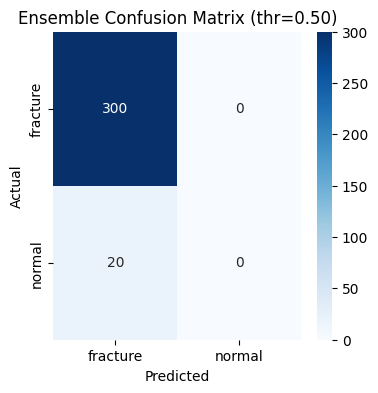

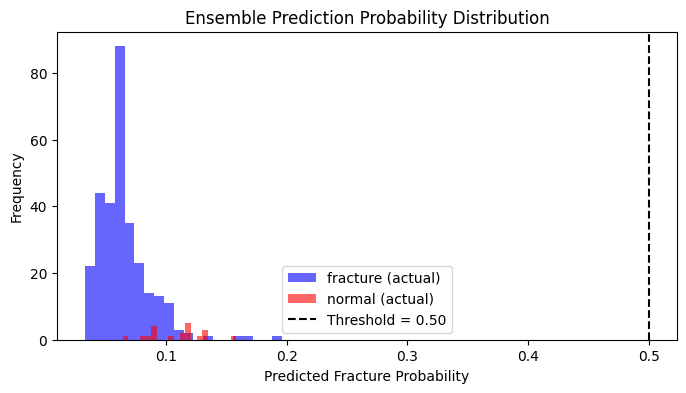

In [17]:

import os, numpy as np, tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


RUN_ENSEMBLE = True
RUN_CNN_MODELS = True


WORK_DIR = "/kaggle/working/bone_fracture_work"

if "test_flow" not in globals():
    raise RuntimeError("test_flow not defined — please run data loading cell first.")


device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f" Using device: {device_name}")


def ensemble_predict(models_list, gen):
    """Average soft predictions (probabilities) from multiple Keras models."""
    preds_all = []
    for i, m in enumerate(models_list, 1):
        print(f"Running model {i}/{len(models_list)}: {m.name}")
        with tf.device(device_name):
            p = m.predict(gen, verbose=0).ravel()
        preds_all.append(p)

    preds_all = np.stack(preds_all, axis=0)
    mean_pred = np.mean(preds_all, axis=0)
    return mean_pred


if RUN_ENSEMBLE and RUN_CNN_MODELS:
    top_models = []
    print(f" Searching recursively for models in: {WORK_DIR}\n")

    
    for root, _, files in os.walk(WORK_DIR):
        for f in sorted(files):
            if f.endswith("_best.h5"):
                path = os.path.join(root, f)
                try:
                    with tf.device(device_name):
                        model = tf.keras.models.load_model(path)
                    top_models.append(model)
                    print(f"✅ Loaded model: {path}")
                except Exception as e:
                    print(f"⚠️ Failed to load {path}: {e}")

    if len(top_models) == 0:
        print(" No saved models found, using current model `m` if available.")
        if "m" in globals():
            top_models = [m]
        else:
            raise RuntimeError(" No models available for ensemble!")

    print(f"\nTotal models used for ensemble: {len(top_models)}")

  
    with tf.device(device_name):
        P = ensemble_predict(top_models, test_flow)

    y_true = np.array(test_flow.classes)
    labels = list(test_flow.class_indices.keys())

   
    best_thr, best_f1 = 0.5, 0
    for t in np.linspace(0.3, 0.7, 21):
        f1 = f1_score(y_true, (P >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_thr = f1, t
    print(f"\n🔹 Optimal threshold for best F1: {best_thr:.2f}")

    yh = (P >= best_thr).astype(int)

    
    print("\n Ensemble Classification Report:")
    print(classification_report(y_true, yh, target_names=labels, digits=4, zero_division=0))

    
    cm = confusion_matrix(y_true, yh)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Ensemble Confusion Matrix (thr={best_thr:.2f})")
    plt.show()

   
    plt.figure(figsize=(8, 4))
    plt.hist(P[y_true == 0], bins=20, alpha=0.6, label=f"{labels[0]} (actual)", color='blue')
    plt.hist(P[y_true == 1], bins=20, alpha=0.6, label=f"{labels[1]} (actual)", color='red')
    plt.axvline(best_thr, color='black', linestyle="--", label=f"Threshold = {best_thr:.2f}")
    plt.title("Ensemble Prediction Probability Distribution")
    plt.xlabel("Predicted Fracture Probability")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

else:
    print(" RUN_ENSEMBLE or RUN_CNN_MODELS is False — set both True to run ensemble evaluation.")


 Detected training folder: /kaggle/input/bone-fracture-dataset/Bone fracture dataset/Bone fracture dataset/Dataset
 Mixt test set created with 20 images at /kaggle/working/mixt_flat
 Using device: /CPU:0
 Loaded: DenseNet121_best.h5
Failed to load EffB0_CBAM_best.h5: Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, name=keras_tensor_7517>',)
  • kwargs={'mask': 'None'}
 Loaded: EffB0_PLAIN_best.h5
 Loaded: EfficientNetB0_best.h5
 Loaded: InceptionV3_best.h5
 Loaded: MobileNetV2_best.h5
 Loaded: NASNetMobile_best.h5
 Loaded: ResNet50_best.h5
 Loaded: VGG16_best.h5
 Loaded: Xception_best.h5


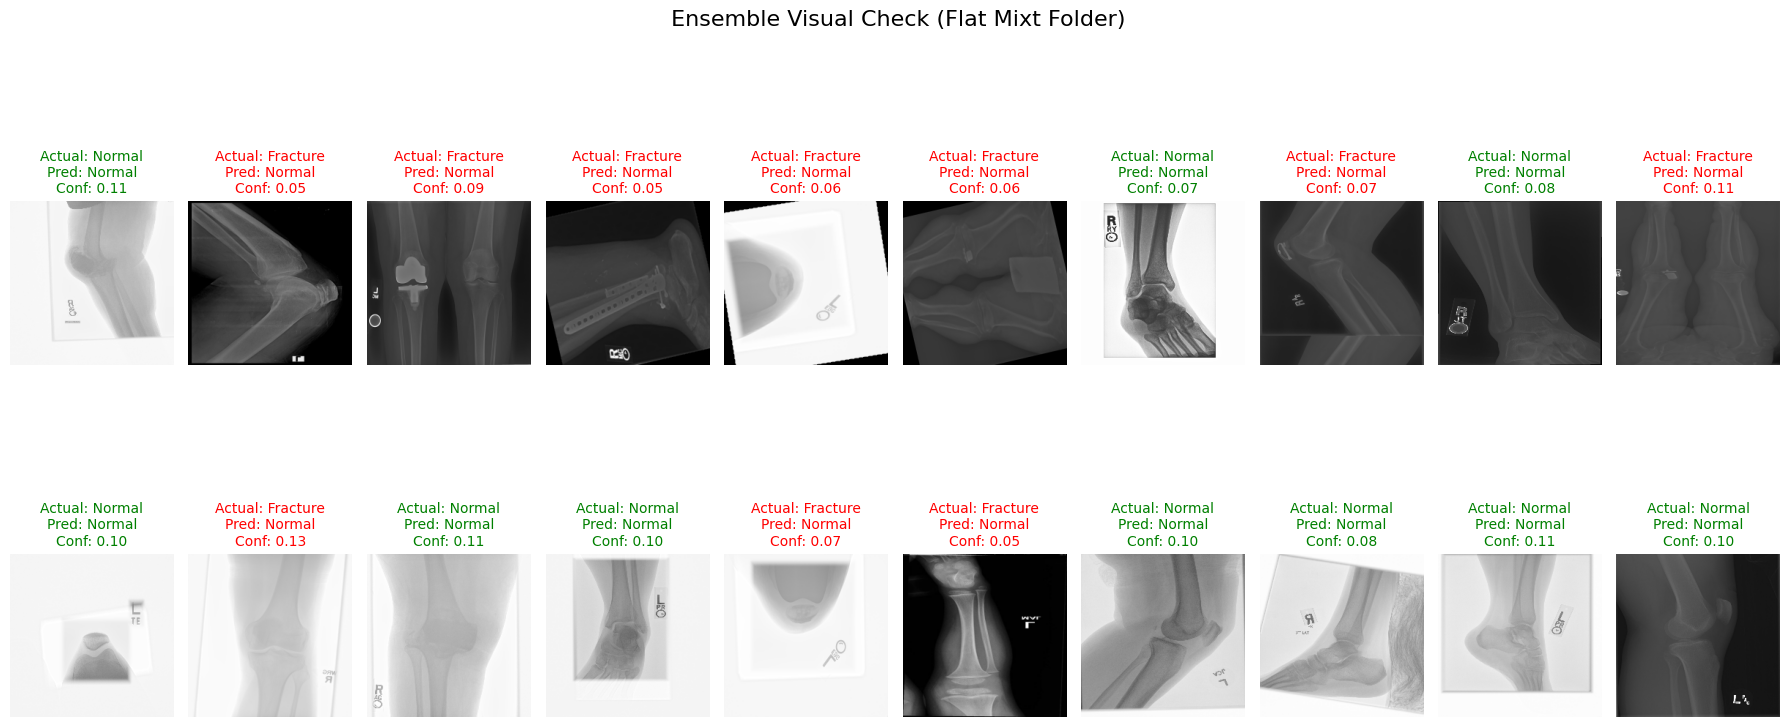

In [18]:
# ==========================================================
#  Locate dataset automatically, build Mixt set, visualize ensemble
# ==========================================================
import os, random, shutil, cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 
root_candidates = [
    "/kaggle/input/bone-fracture-dataset/",
    "/kaggle/input/bone-fracture-dataset-only/",
    "/kaggle/input/",
]

SOURCE_TRAIN = None
for root in root_candidates:
    for subdir, dirs, files in os.walk(root):
        if "fracture" in dirs and "normal" in dirs:
            SOURCE_TRAIN = subdir
            break
    if SOURCE_TRAIN:
        break

if not SOURCE_TRAIN:
    raise FileNotFoundError(" Could not find dataset folders containing 'fracture' and 'normal'!")

print(f" Detected training folder: {SOURCE_TRAIN}")


MIXT_DIR = "/kaggle/working/mixt_flat"
WORK_DIR = "/kaggle/working/bone_fracture_work"
IMG_SIZE = (224, 224)
NUM_SAMPLES_PER_CLASS = 10  


if os.path.exists(MIXT_DIR):
    shutil.rmtree(MIXT_DIR)
os.makedirs(MIXT_DIR, exist_ok=True)

def copy_random_images(class_name, n=10):
    src_class_path = os.path.join(SOURCE_TRAIN, class_name)
    if not os.path.exists(src_class_path):
        raise FileNotFoundError(f" Folder not found: {src_class_path}")
    images = [f for f in os.listdir(src_class_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
    if len(images) == 0:
        raise ValueError(f" No images found in {src_class_path}")
    selected = random.sample(images, min(n, len(images)))
    for img in selected:
        shutil.copy2(os.path.join(src_class_path, img), os.path.join(MIXT_DIR, f"{class_name}_{img}"))

copy_random_images("fracture", NUM_SAMPLES_PER_CLASS)
copy_random_images("normal", NUM_SAMPLES_PER_CLASS)
print(f" Mixt test set created with {len(os.listdir(MIXT_DIR))} images at {MIXT_DIR}")


device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f" Using device: {device_name}")

models_list = []
for f in sorted(os.listdir(WORK_DIR)):
    if f.endswith("_best.h5"):
        model_path = os.path.join(WORK_DIR, f)
        try:
            with tf.device(device_name):
                model = tf.keras.models.load_model(model_path)
            models_list.append(model)
            print(f" Loaded: {f}")
        except Exception as e:
            print(f"Failed to load {f}: {e}")

if len(models_list) == 0:
    raise RuntimeError(" No trained models found in bone_fracture_work!")


def ensemble_predict_image(img_path):
    """Predicts average probability of 'fracture' using ensemble of models."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    arr = np.expand_dims(img.astype("float32") / 255.0, axis=0)

    preds = []
    for m in models_list:
        with tf.device(device_name):
            p = m.predict(arr, verbose=0)[0][0]
        preds.append(p)
    mean_prob = np.mean(preds)
    return mean_prob, img


images = [os.path.join(MIXT_DIR, f) for f in os.listdir(MIXT_DIR)
          if f.lower().endswith(('jpg', 'jpeg', 'png'))]
random.shuffle(images)

plt.figure(figsize=(18, 9))
for i, img_path in enumerate(images[:NUM_SAMPLES_PER_CLASS * 2]):
    prob, img = ensemble_predict_image(img_path)
    pred = "Fracture" if prob >= 0.5 else "Normal"
    actual = "Fracture" if "fracture" in img_path.lower() else "Normal"
    color = "green" if pred == actual else "red"

    plt.subplot(2, NUM_SAMPLES_PER_CLASS, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Actual: {actual}\nPred: {pred}\nConf: {prob:.2f}", color=color, fontsize=10)

plt.suptitle(" Ensemble Visual Check (Flat Mixt Folder)", fontsize=16)
plt.tight_layout()
plt.show()


In [19]:
# ==========================================================
# 5-Fold Cross-Validation 
# ==========================================================
import os, shutil, glob, gc
import numpy as np
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf


RUN_FIVE_FOLD = True
FULL_EPOCHS = 5
DROP = 0.5
L2 = 1e-4
IMG_SIZE = (224, 224)


if tf.config.list_physical_devices('GPU'):
    device_name = "/GPU:0"
    print("Using GPU for K-Fold training.")
else:
    device_name = "/CPU:0"
    print(" No GPU found — using CPU for K-Fold training.")


def build_efficientnet(img_size=IMG_SIZE, drop=DROP, l2=L2):
    """Reusable EfficientNetB0 binary classifier."""
    from tensorflow.keras import layers, models, regularizers
    from tensorflow.keras.applications import EfficientNetB0
    inp = layers.Input(shape=(img_size[0], img_size[1], 3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(l2))(x)
    m = models.Model(inp, out, name="EffNetB0_CV")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m, base


def run_kfold(arch="EfficientNetB0", k=5):
    """Performs K-fold cross-validation with stratified splits."""
    files, labels = [], []
    for c in classes:
        for p in glob.glob(os.path.join(TRAIN_DIR, c, "*")):
            files.append(p)
            labels.append(c)
    files, labels = np.array(files), np.array(labels)
    y_enc = (labels == classes[1]).astype(int)

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = []

    for fold, (tr, va) in enumerate(skf.split(files, y_enc), 1):
        print(f"\n========== Fold {fold}/{k} ==========")
        tmp_tr = os.path.join(WORK_DIR, f"cv_tr_{fold}")
        tmp_va = os.path.join(WORK_DIR, f"cv_va_{fold}")

    
        for pth in [tmp_tr, tmp_va]:
            if os.path.exists(pth):
                shutil.rmtree(pth)
            for c in classes:
                os.makedirs(os.path.join(pth, c), exist_ok=True)

       
        for i in tr:
            shutil.copy2(files[i], os.path.join(tmp_tr, labels[i], os.path.basename(files[i])))
        for i in va:
            shutil.copy2(files[i], os.path.join(tmp_va, labels[i], os.path.basename(files[i])))

        
        train_gen = ImageDataGenerator(preprocessing_function=preprocessing_function).flow_from_directory(
            tmp_tr, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary")
        val_gen = ImageDataGenerator(preprocessing_function=preprocessing_function).flow_from_directory(
            tmp_va, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

       
        with tf.device(device_name):
            model, _ = build_efficientnet()
            cb = [EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1)]
            model.fit(train_gen, validation_data=val_gen,
                      epochs=FULL_EPOCHS, callbacks=cb, verbose=1)

           
            _, acc = model.evaluate(val_gen, verbose=0)
            print(f"Fold {fold} accuracy: {acc:.4f}")
            scores.append(acc)

        
        shutil.rmtree(tmp_tr, ignore_errors=True)
        shutil.rmtree(tmp_va, ignore_errors=True)
        tf.keras.backend.clear_session()
        gc.collect()

    print("\nCross-validation results:")
    print("Accuracies:", [round(s, 4) for s in scores])
    print("Mean accuracy:", round(float(np.mean(scores)), 4))
    return scores


if RUN_FIVE_FOLD:
    cv_scores = run_kfold("EfficientNetB0", k=5)
else:
    print("RUN_FIVE_FOLD is False — skipping cross-validation.")


 No GPU found — using CPU for K-Fold training.

========== Fold 1/5 ==========
Found 1190 images belonging to 2 classes.
Found 298 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 75s 736ms/step - accuracy: 0.9205 - loss: 0.2955 - val_accuracy: 0.9396 - val_loss: 0.2287
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 664ms/step - accuracy: 0.9400 - loss: 0.2317 - val_accuracy: 0.9396 - val_loss: 0.2286
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 663ms/step - accuracy: 0.9379 - loss: 0.2383 - val_accuracy: 0.9396 - val_loss: 0.2307
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 667ms/step - accuracy: 0.9313 - loss: 0.2613 - val_accuracy: 0.9396 - val_loss: 0.2287
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Fold 1 accuracy: 0.9396

========== Fold 2/5 ==========
Found 1190 images belonging to 2 classes.
Found 298 images belonging to 2 classes.
Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 73s 743ms/step - accuracy: 0.8407 - loss: 0.3872 - val_accuracy: 0.9396 - val_loss: 0.2287
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 668ms/step - accuracy: 0.9304 - loss: 0.2590 - val_accuracy: 0.9396 - val_loss: 0.2383
Epoch 3/5
